# Data Analysis & (EDA) Exploratory Data Analysis
1. Data Loading
2. Handling Missing Data
3. Encoding Data
4. Cleaning Outliers
5. Train Test Splitting
6. Feature Scaling


## 1. Data Loading


In [16]:
import pandas as pd


In [17]:
adres = "data/50_StartupswithNaN.csv"
df = pd.read_csv(adres)

Veriyi tanımak
* head
* tail
* describe
* info
* shape


In [18]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,NaN,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,NaN,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,NaN,Florida,166187.94


In [19]:
df.tail()

,R&D Spend,Administration,Marketing Spend,State,Profit
45,1000.23,124153.04,1903.93,New York,64926.08
46,1315.46,115816.21,297114.46,Florida,49490.75
47,0.00,135426.92,0.00,California,42559.73
48,542.05,51743.15,0.00,New York,35673.41
49,0.00,116983.80,45173.06,California,14681.40


In [20]:
df.shape

(50, 5)

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   48 non-null     float64
 2   Marketing Spend  48 non-null     float64
 3   State            47 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [22]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,48.000000,48.000000,50.000000
mean,73721.615600,120058.798542,206984.313125,112012.639200
std,45902.256482,27859.615011,122598.752209,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,102579.505000,125324.665000,90138.902500
50%,73051.080000,122107.195000,208157.655000,107978.190000
75%,101602.800000,140698.865000,298932.675000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


## 2. Handling Missing Data


In [23]:
adres = "data/sample.csv"
df = pd.read_csv(adres)
df.head()

,Ulke,Cinsiyet,Gelir,Yas,MemTip
0,NaN,Kadın,20000.0,NaN,1
1,NaN,Erkek,15000.0,32.0,2
2,İngiltere,NaN,23000.0,NaN,3
3,Turkiye,Kadın,20000.0,45.0,1
4,Fransa,Erkek,15000.0,23.0,2


In [24]:
df.isna().sum()

Ulke        5
Cinsiyet    4
Gelir       1
Yas         4
MemTip      0
dtype: int64

In [25]:
df.isnull().sum()

Ulke        5
Cinsiyet    4
Gelir       1
Yas         4
MemTip      0
dtype: int64

### 2.1. Delete Data
* Delete Row
* Delete Column

In [26]:
dfOrn1 = df.copy()
dfOrn1Clean = dfOrn1.dropna(axis=0) # Delete Row
dfOrn1Clean.isna().sum()

Ulke        0
Cinsiyet    0
Gelir       0
Yas         0
MemTip      0
dtype: int64

In [27]:
dfOrn1Clean.shape

(6, 5)

In [28]:
dfOrn1.shape

(16, 5)

In [29]:
dfOrn2 = df.copy()
dfOrn2Clean = dfOrn2.dropna(axis=1) # Column Row
dfOrn2Clean.isna().sum()

MemTip    0
dtype: int64

2.2. Impute Data
* mean,median,mode
* Simple Imputer
* Iterative Imputer


#### mean

In [30]:
dfOrn3 = df.copy()
dfOrn3.Yas

0      NaN
1     32.0
2      NaN
3     45.0
4     23.0
5     12.0
6     45.0
7      NaN
8     12.0
9     45.0
10    46.0
11     NaN
12    32.0
13    32.0
14    32.0
15    45.0
Name: Yas, dtype: float64

In [31]:
dfOrn3["Yas"] = dfOrn3["Yas"].fillna(dfOrn3["Yas"].mean())

#### mode

In [32]:
dfOrn4 = df.copy()
dfOrn4.Yas

0      NaN
1     32.0
2      NaN
3     45.0
4     23.0
5     12.0
6     45.0
7      NaN
8     12.0
9     45.0
10    46.0
11     NaN
12    32.0
13    32.0
14    32.0
15    45.0
Name: Yas, dtype: float64

In [33]:
dfOrn4["Yas"] = dfOrn4["Yas"].fillna(dfOrn4["Yas"].mode()[0])

In [34]:
dfOrn4.Yas

0     32.0
1     32.0
2     32.0
3     45.0
4     23.0
5     12.0
6     45.0
7     32.0
8     12.0
9     45.0
10    46.0
11    32.0
12    32.0
13    32.0
14    32.0
15    45.0
Name: Yas, dtype: float64

#### median

In [35]:
dfOrn5 = df.copy()
dfOrn5.Yas

0      NaN
1     32.0
2      NaN
3     45.0
4     23.0
5     12.0
6     45.0
7      NaN
8     12.0
9     45.0
10    46.0
11     NaN
12    32.0
13    32.0
14    32.0
15    45.0
Name: Yas, dtype: float64

In [36]:
dfOrn5["Yas"] = dfOrn5["Yas"].fillna(dfOrn5["Yas"].median())

In [37]:
dfOrn5.Yas

0     32.0
1     32.0
2     32.0
3     45.0
4     23.0
5     12.0
6     45.0
7     32.0
8     12.0
9     45.0
10    46.0
11    32.0
12    32.0
13    32.0
14    32.0
15    45.0
Name: Yas, dtype: float64

In [38]:
import numpy as np
veri = pd.Series(range(20))
veri.loc[2:4] = np.nan
veri.loc[7:10] = np.nan
veri

0      0.0
1      1.0
2      NaN
3      NaN
4      NaN
5      5.0
6      6.0
7      NaN
8      NaN
9      NaN
10     NaN
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
16    16.0
17    17.0
18    18.0
19    19.0
dtype: float64

#### ffill,bfill,interpolate

In [39]:
veri.ffill()

0      0.0
1      1.0
2      1.0
3      1.0
4      1.0
5      5.0
6      6.0
7      6.0
8      6.0
9      6.0
10     6.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
16    16.0
17    17.0
18    18.0
19    19.0
dtype: float64

In [40]:
veri.bfill()

0      0.0
1      1.0
2      5.0
3      5.0
4      5.0
5      5.0
6      6.0
7     11.0
8     11.0
9     11.0
10    11.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
16    16.0
17    17.0
18    18.0
19    19.0
dtype: float64

In [41]:
veri.interpolate()

0      0.0
1      1.0
2      2.0
3      3.0
4      4.0
5      5.0
6      6.0
7      7.0
8      8.0
9      9.0
10    10.0
11    11.0
12    12.0
13    13.0
14    14.0
15    15.0
16    16.0
17    17.0
18    18.0
19    19.0
dtype: float64

#### Simple Imputer

In [42]:
# !pip install scikit-learn
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")
dfOrn6 = df.copy()
imputer.fit_transform(dfOrn6[["Ulke"]])
pd.DataFrame(data=imputer.fit_transform(dfOrn6[["Ulke"]]))


ModuleNotFoundError: No module named 'sklearn'

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="constant",fill_value="missing")
dfOrn6 = df.copy()
imputer.fit_transform(dfOrn6)
dforn6 = pd.DataFrame(data=imputer.fit_transform(dfOrn6))
dforn6.columns = df.columns
dforn6

,Ulke,Cinsiyet,Gelir,Yas,MemTip
0,missing,Kadın,20000.0,missing,1
1,missing,Erkek,15000.0,32.0,2
2,İngiltere,missing,23000.0,missing,3
3,Turkiye,Kadın,20000.0,45.0,1
4,Fransa,Erkek,15000.0,23.0,2
5,missing,missing,23000.0,12.0,3
6,Almanya,Kadın,20000.0,45.0,1
7,Turkiye,Erkek,18000.0,missing,2
8,İngiltere,missing,23000.0,12.0,3
9,Almanya,Kadın,missing,45.0,1


In [ ]:
df

,Ulke,Cinsiyet,Gelir,Yas,MemTip
0,NaN,Kadın,20000.0,NaN,1
1,NaN,Erkek,15000.0,32.0,2
2,İngiltere,NaN,23000.0,NaN,3
3,Turkiye,Kadın,20000.0,45.0,1
4,Fransa,Erkek,15000.0,23.0,2
5,NaN,NaN,23000.0,12.0,3
6,Almanya,Kadın,20000.0,45.0,1
7,Turkiye,Erkek,18000.0,NaN,2
8,İngiltere,NaN,23000.0,12.0,3
9,Almanya,Kadın,NaN,45.0,1


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder
dfOrn7 = df.copy()
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="most_frequent")
dfOrn7 = df.copy()
dfOrn7["Ulke"] = imputer.fit_transform(dfOrn7[["Ulke"]])
dfOrn7["Cinsiyet"] = imputer.fit_transform(dfOrn7[["Cinsiyet"]])
le = LabelEncoder()
le.fit(dfOrn7["Ulke"])
dfOrn7["EnUlke"] = le.transform(dfOrn7["Ulke"])
le.fit(dfOrn7["Cinsiyet"])
dfOrn7["EnCinsiyet"] = le.transform(dfOrn7["Cinsiyet"])
dfOrn7

ValueError: 2

In [ ]:
itr_imp = IterativeImputer()
itr_imp.fit_transform(dfOrn7[["EnUlke","EnCinsiyet","Yas"]])
dfSonuc = pd.DataFrame(data=itr_imp.fit_transform(dfOrn7[["EnUlke","EnCinsiyet","Yas"]]))
dfSonuc.columns = ["a","b","Yas"]
dfOrn7["YasSonuc"] = dfSonuc["Yas"]

KeyError: "['EnUlke', 'EnCinsiyet'] not in index"

In [ ]:
dfOrn7

,Ulke,Cinsiyet,Gelir,Yas,MemTip,EnUlke,EnCinsiyet,YasSonuc
0,İngiltere,Kadın,20000.0,NaN,1,4,1,32.903370
1,İngiltere,Erkek,15000.0,32.0,2,4,0,32.000000
2,İngiltere,Erkek,23000.0,NaN,3,4,0,30.178346
3,Turkiye,Kadın,20000.0,45.0,1,3,1,45.000000
4,Fransa,Erkek,15000.0,23.0,2,2,0,23.000000
5,İngiltere,Erkek,23000.0,12.0,3,4,0,12.000000
6,Almanya,Kadın,20000.0,45.0,1,0,1,45.000000
7,Turkiye,Erkek,18000.0,NaN,2,3,0,32.508325
8,İngiltere,Erkek,23000.0,12.0,3,4,0,12.000000
9,Almanya,Kadın,NaN,45.0,1,0,1,45.000000


In [ ]:
# Yapılan değişikliklerin veri setine uygulanması
dfOrn7["Yas"] = dfOrn7["YasSonuc"]
dfOrn7['Gelir'] = dfOrn7["Gelir"].fillna(dfOrn7["Gelir"].mean())


In [ ]:
dfOrn7.to_csv("SampleV1.csv")
df = dfOrn7.copy()

## 3. Encoding Data
* Encoding Dependent Variables
* Encoding Independent Variables

### Encoding Independent Variable

In [ ]:
df["Ulke"].unique()


array(['İngiltere', 'Turkiye', 'Fransa', 'Almanya', 'Avusturya',
       'İspanya'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
pd.DataFrame(data=enc.fit_transform(df[["Ulke"]]).toarray())

,0,1,2,3,4,5
0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,1.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,1.0,0.0,0.0
8,0.0,0.0,0.0,0.0,1.0,0.0
9,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df["Ulke"]

0     İngiltere
1     İngiltere
2     İngiltere
3       Turkiye
4        Fransa
5     İngiltere
6       Almanya
7       Turkiye
8     İngiltere
9       Almanya
10    Avusturya
11    İngiltere
12      İspanya
13    İngiltere
14      İspanya
15    İngiltere
Name: Ulke, dtype: object

In [ ]:
df["Cinsiyet"].unique()

array(['Kadın', 'Erkek'], dtype=object)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
pd.DataFrame(data=enc.fit_transform(df[["Cinsiyet"]]).toarray())

,0,1
0,0.0,1.0
1,1.0,0.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0
5,1.0,0.0
6,0.0,1.0
7,1.0,0.0
8,1.0,0.0
9,0.0,1.0


In [ ]:
df

,Ulke,Cinsiyet,Gelir,Yas,MemTip,EnUlke,EnCinsiyet,YasSonuc
0,İngiltere,Kadın,20000.0,32.903370,1,4,1,32.903370
1,İngiltere,Erkek,15000.0,32.000000,2,4,0,32.000000
2,İngiltere,Erkek,23000.0,30.178346,3,4,0,30.178346
3,Turkiye,Kadın,20000.0,45.000000,1,3,1,45.000000
4,Fransa,Erkek,15000.0,23.000000,2,2,0,23.000000
5,İngiltere,Erkek,23000.0,12.000000,3,4,0,12.000000
6,Almanya,Kadın,20000.0,45.000000,1,0,1,45.000000
7,Turkiye,Erkek,18000.0,32.508325,2,3,0,32.508325
8,İngiltere,Erkek,23000.0,12.000000,3,4,0,12.000000
9,Almanya,Kadın,20200.0,45.000000,1,0,1,45.000000


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(),[0,1])],remainder="passthrough")
encoded = pd.DataFrame(data=ct.fit_transform(df))
encoded

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,20000.0,32.903370,1.0,4.0,1.0,32.903370
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,15000.0,32.000000,2.0,4.0,0.0,32.000000
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,23000.0,30.178346,3.0,4.0,0.0,30.178346
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,20000.0,45.000000,1.0,3.0,1.0,45.000000
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,15000.0,23.000000,2.0,2.0,0.0,23.000000
5,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,23000.0,12.000000,3.0,4.0,0.0,12.000000
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20000.0,45.000000,1.0,0.0,1.0,45.000000
7,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,18000.0,32.508325,2.0,3.0,0.0,32.508325
8,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,23000.0,12.000000,3.0,4.0,0.0,12.000000
9,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,20200.0,45.000000,1.0,0.0,1.0,45.000000


In [ ]:
encoded.drop([6,13],axis=1,inplace=True)
encoded.head()

,0,1,2,3,4,5,7,8,9,10,11,12
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,20000.0,32.903370,1.0,4.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,15000.0,32.000000,2.0,4.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,23000.0,30.178346,3.0,4.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,20000.0,45.000000,1.0,3.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,15000.0,23.000000,2.0,2.0,0.0


In [ ]:
encoded.columns = list(range(len(encoded.columns)))
encoded.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,20000.0,32.903370,1.0,4.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,15000.0,32.000000,2.0,4.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,23000.0,30.178346,3.0,4.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,1.0,20000.0,45.000000,1.0,3.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,15000.0,23.000000,2.0,2.0,0.0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit_transform(ornek["Karar"])

array([0, 3, 1, 1, 1, 3, 3, 1, 1, 0, 2, 0, 2, 0, 0, 2, 0, 3, 3, 3, 0, 1,
       3, 1, 2, 3, 3, 0, 3, 2, 0, 3, 0, 0, 2, 0, 1, 0, 2, 3, 1, 2, 3, 2,
       0, 1, 0, 3, 3, 0, 2, 0, 2, 1, 0, 1, 1, 0, 3, 1, 0, 2, 0, 2, 3, 0,
       3, 2, 3, 3, 2, 2, 0, 0, 3, 0, 2, 2, 1, 1, 1, 0, 2, 0, 3, 3, 1, 2,
       1, 2, 3, 0, 0, 2, 2, 0, 1, 3, 0, 1, 1, 0, 3, 0, 0, 2, 0, 1, 1, 2,
       0, 1, 2, 2, 2, 3, 1, 3, 0, 0, 0, 0, 3, 0, 1, 0, 0, 3, 2, 1, 2, 3,
       0, 0, 2, 3, 3, 3, 0, 1, 1, 1, 2, 0, 3, 2, 3, 0, 2, 0, 2, 3, 3, 2,
       3, 1, 3, 3, 3, 2, 2, 3, 2, 2, 0, 2, 2, 3, 0, 3, 2, 3, 0, 2, 3, 1,
       1, 3, 0, 0, 0, 2, 0, 2, 2, 3, 0, 0, 0, 3, 1, 2, 2, 0, 0, 1, 0, 1,
       3, 2])

In [ ]:
# Comparison of Transformer-Based Models Trained in Turkish and Different Languages on Turkish Natural Language Processing Problems

## 4. Cleaning Outliers

In [ ]:
from sklearn.datasets import load_diabetes
diabet = load_diabetes()
sutunadlari = diabet.feature_names
df = pd.DataFrame(diabet.data)
df.columns = sutunadlari
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
adres = "boston.csv"
df = pd.read_csv(adres)
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


<Axes: xlabel='crim'>

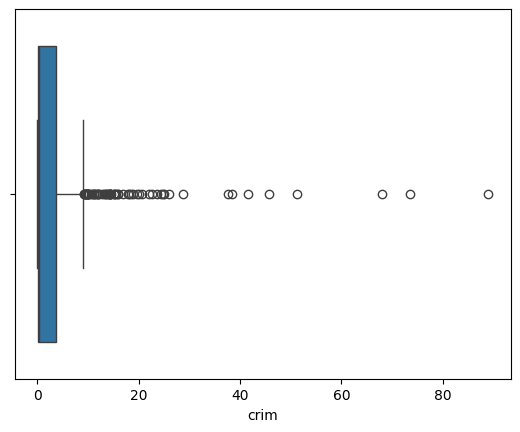

In [ ]:
import seaborn as sns
sns.boxplot(x=df["crim"])

In [ ]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


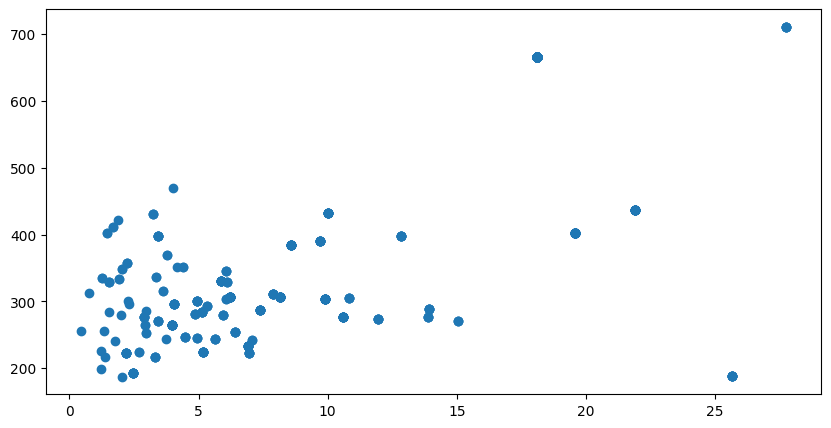

In [ ]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(figsize=(10,5))
ax.scatter(df["indus"],df["tax"])
plt.show()

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR =  Q3-Q1
kesinti = IQR * 1.5
dusuk,yuksek = Q1 - kesinti,Q3  + kesinti

In [ ]:
df[(df<dusuk)|(df>yuksek)].isna().sum()

,0
crim,440
zn,438
indus,506
chas,471
nox,506
rm,476
age,506
dis,501
rad,506
tax,506


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [ ]:
df_out = df[~((df < dusuk) | (df > yuksek)).any(axis=1)]
df_out

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


#### Z - Score


In [ ]:
from scipy import stats
import numpy as np
z = np.abs(stats.zscore(df))
print(z)

[[0.41978194 0.28482986 1.2879095  ... 0.44105193 1.0755623  0.15968566]
 [0.41733926 0.48772236 0.59338101 ... 0.44105193 0.49243937 0.10152429]
 [0.41734159 0.48772236 0.59338101 ... 0.39642699 1.2087274  1.32424667]
 ...
 [0.41344658 0.48772236 0.11573841 ... 0.44105193 0.98304761 0.14880191]
 [0.40776407 0.48772236 0.11573841 ... 0.4032249  0.86530163 0.0579893 ]
 [0.41500016 0.48772236 0.11573841 ... 0.44105193 0.66905833 1.15724782]]


In [ ]:
threshold = 3
print(np.where(z > 3))

(array([ 55,  56,  57, 102, 141, 142, 152, 154, 155, 160, 162, 163, 199,
       200, 201, 202, 203, 204, 208, 209, 210, 211, 212, 216, 218, 219,
       220, 221, 222, 225, 234, 236, 256, 257, 262, 269, 273, 274, 276,
       277, 282, 283, 283, 284, 347, 351, 352, 353, 353, 354, 355, 356,
       357, 358, 363, 364, 364, 365, 367, 369, 370, 372, 373, 374, 374,
       380, 398, 404, 405, 406, 410, 410, 411, 412, 412, 414, 414, 415,
       416, 418, 418, 419, 423, 424, 425, 426, 427, 427, 429, 431, 436,
       437, 438, 445, 450, 454, 455, 456, 457, 466]), array([ 1,  1,  1, 11, 12,  3,  3,  3,  3,  3,  3,  3,  1,  1,  1,  1,  1,
        1,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  5,  3,  3,  1,  5,
        5,  3,  3,  3,  3,  3,  3,  1,  3,  1,  1,  7,  7,  1,  7,  7,  7,
        3,  3,  3,  3,  3,  5,  5,  5,  3,  3,  3, 12,  5, 12,  0,  0,  0,
        0,  5,  0, 11, 11, 11, 12,  0, 12, 11, 11,  0, 11, 11, 11, 11, 11,
       11,  0, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11]

In [ ]:
z = np.abs(stats.zscore(df["crim"]))
z

array([4.19781939e-01, 4.17339264e-01, 4.17341592e-01, 4.16750416e-01,
       4.12481846e-01, 4.17043676e-01, 4.10242825e-01, 4.03695667e-01,
       3.95934736e-01, 4.00729313e-01, 3.94346241e-01, 4.06847054e-01,
       4.09603936e-01, 3.47230211e-01, 3.46275950e-01, 3.47506015e-01,
       2.97868176e-01, 3.29257528e-01, 3.27103460e-01, 3.36053725e-01,
       2.74842569e-01, 3.21362768e-01, 2.77090899e-01, 3.05490623e-01,
       3.33207236e-01, 3.22701061e-01, 3.42325079e-01, 3.09291373e-01,
       3.30562072e-01, 3.03859070e-01, 2.88921402e-01, 2.62864272e-01,
       2.58992534e-01, 2.86488038e-01, 2.32828340e-01, 4.13049747e-01,
       4.09178010e-01, 4.11191267e-01, 4.00146283e-01, 4.17302025e-01,
       4.16608441e-01, 4.05686813e-01, 4.04050605e-01, 4.01972179e-01,
       4.06239586e-01, 4.00568718e-01, 3.98597355e-01, 3.93836526e-01,
       3.90973745e-01, 3.94942072e-01, 4.10191621e-01, 4.15470310e-01,
       4.14279812e-01, 4.14720867e-01, 4.18934742e-01, 4.18991764e-01,
      

In [ ]:
print(np.where(z>3))

(array([380, 398, 404, 405, 410, 414, 418, 427]),)


In [ ]:
df.loc[(380, 398, 404, 405, 410, 414, 418, 427),:]

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
380,88.9762,0.0,18.1,0,0.671,6.968,91.9,1.4165,24,666,20.2,396.90,17.21,10.4
398,38.3518,0.0,18.1,0,0.693,5.453,100.0,1.4896,24,666,20.2,396.90,30.59,5.0
404,41.5292,0.0,18.1,0,0.693,5.531,85.4,1.6074,24,666,20.2,329.46,27.38,8.5
405,67.9208,0.0,18.1,0,0.693,5.683,100.0,1.4254,24,666,20.2,384.97,22.98,5.0
410,51.1358,0.0,18.1,0,0.597,5.757,100.0,1.4130,24,666,20.2,2.60,10.11,15.0
414,45.7461,0.0,18.1,0,0.693,4.519,100.0,1.6582,24,666,20.2,88.27,36.98,7.0
418,73.5341,0.0,18.1,0,0.679,5.957,100.0,1.8026,24,666,20.2,16.45,20.62,8.8
427,37.6619,0.0,18.1,0,0.679,6.202,78.7,1.8629,24,666,20.2,18.82,14.52,10.9


In [ ]:
dfTemiz = df.drop(list(*np.where(z>1)),axis=0)
dfTemiz

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


<Axes: xlabel='crim'>

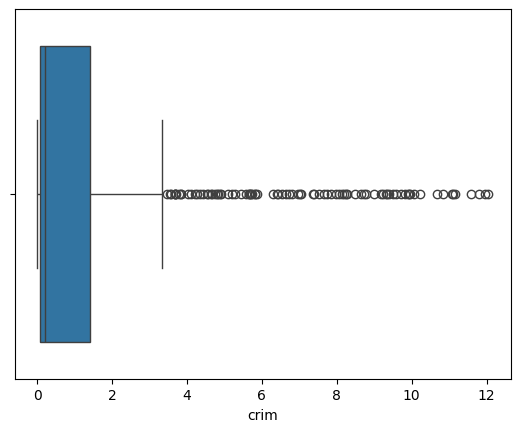

In [ ]:
sns.boxplot(x=dfTemiz["crim"])

<Axes: xlabel='crim'>

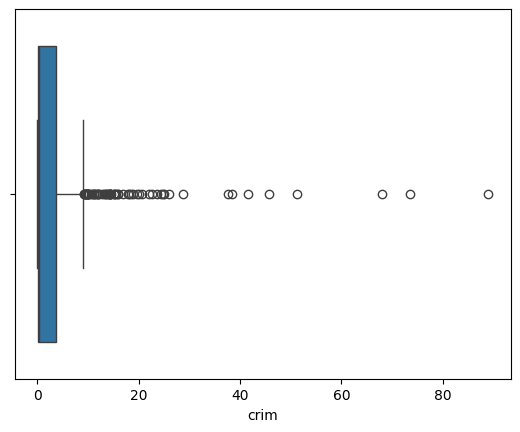

In [ ]:
sns.boxplot(x=df["crim"])

<Axes: >

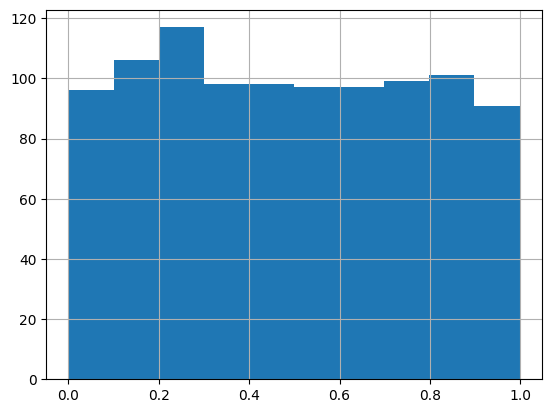

In [ ]:
pd.Series(np.random.random(1000)).hist()

<Axes: >

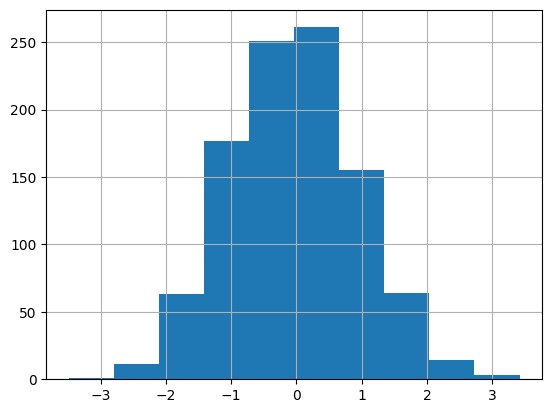

In [ ]:
pd.Series(np.random.randn(1000)).hist()

5. Train Test Splitting

In [ ]:
adres = "heart.csv"
df = pd.read_csv(adres)
df.head()

,AGE_50,MD_50,SBP_50,DBP_50,HT_50,WT_50,CHOL_50,SES,CL_STATUS,MD_62,SBP_62,DBP_62,CHOL_62,WT_62,IHD_DX,DEATH
0,42,1,110,65,64,147,291,2,8,4,120,78,271,146,2,1
1,53,1,130,72,69,167,278,1,6,2,122,68,250,165,9,1
2,53,2,120,90,70,222,342,4,8,1,132,90,304,223,2,1
3,48,4,120,80,72,229,239,4,8,2,118,68,209,227,3,1
4,53,3,118,74,66,134,243,3,8,5,118,56,261,138,2,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   AGE_50     200 non-null    int64
 1   MD_50      200 non-null    int64
 2   SBP_50     200 non-null    int64
 3   DBP_50     200 non-null    int64
 4   HT_50      200 non-null    int64
 5   WT_50      200 non-null    int64
 6   CHOL_50    200 non-null    int64
 7   SES        200 non-null    int64
 8   CL_STATUS  200 non-null    int64
 9   MD_62      200 non-null    int64
 10  SBP_62     200 non-null    int64
 11  DBP_62     200 non-null    int64
 12  CHOL_62    200 non-null    int64
 13  WT_62      200 non-null    int64
 14  IHD_DX     200 non-null    int64
 15  DEATH      200 non-null    int64
dtypes: int64(16)
memory usage: 25.1 KB


In [ ]:
from sklearn.model_selection import train_test_split
Train,Test = train_test_split(df,test_size=0.2,random_state=42,shuffle=True,stratify=y)

NameError: name 'y' is not defined

In [ ]:
y = df["DEATH"].values
y

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0])

In [ ]:
X = df.drop("DEATH",axis=1).values
X

array([[ 42,   1, 110, ..., 271, 146,   2],
       [ 53,   1, 130, ..., 250, 165,   9],
       [ 53,   2, 120, ..., 304, 223,   2],
       ...,
       [ 20,   3, 130, ..., 274, 158,   0],
       [ 46,   3, 140, ..., 160, 157,   0],
       [ 36,   1, 100, ..., 251, 152,   0]])

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
pd.Series(y_train).value_counts()

0    109
1     51
dtype: int64

In [ ]:
pd.Series(y_test).value_counts()

0    27
1    13
dtype: int64